In [ ]:

import surprise
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

from surprise import Dataset
from surprise import BaselineOnly, KNNBasic, KNNWithMeans, SVD, NMF
from surprise import accuracy
from surprise.model_selection import cross_validate, train_test_split

from scipy.sparse import coo_matrix
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

%config InlineBackend.figure_format = 'retina'

# Load the data

In [2]:
ml_dataset = surprise.Dataset.load_from_file(
    "mvlenssmall/movielenssmall.csv", surprise.Reader()
)
ml_df = pd.read_csv(
    "mvlenssmall/movielenssmall.csv",
    names=["uid", "iid", "rating"],
    header=None,
    sep="\s+"
)
iid2name = {}
with open("mvlenssmall/titres.csv", "r") as file:
    for line in file:
        iid, name = line.split(" ", 1)
        name = name[:-1]
        iid2name[iid] = name

# Preliminary analysis

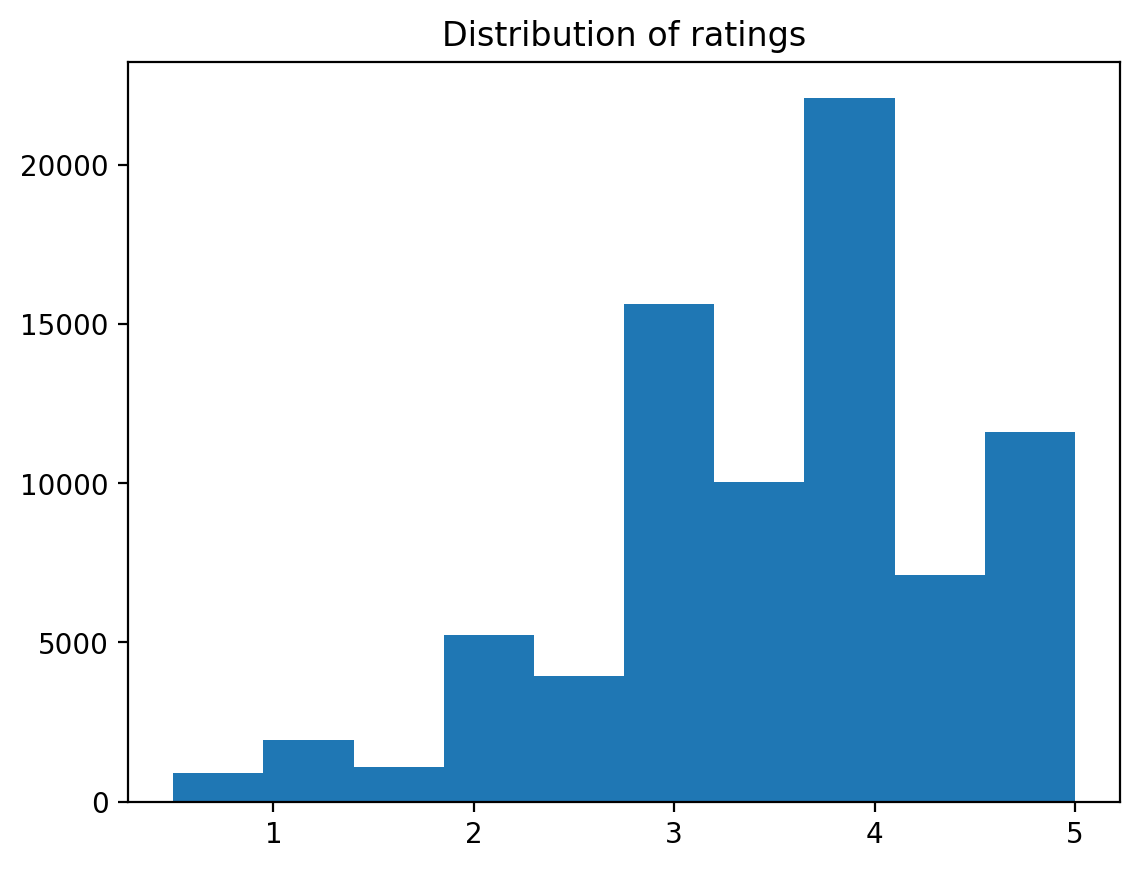

In [3]:
ml_df.rating.hist(grid=False)
plt.title("Distribution of ratings")
plt.show()

So ratings are rather "positive"

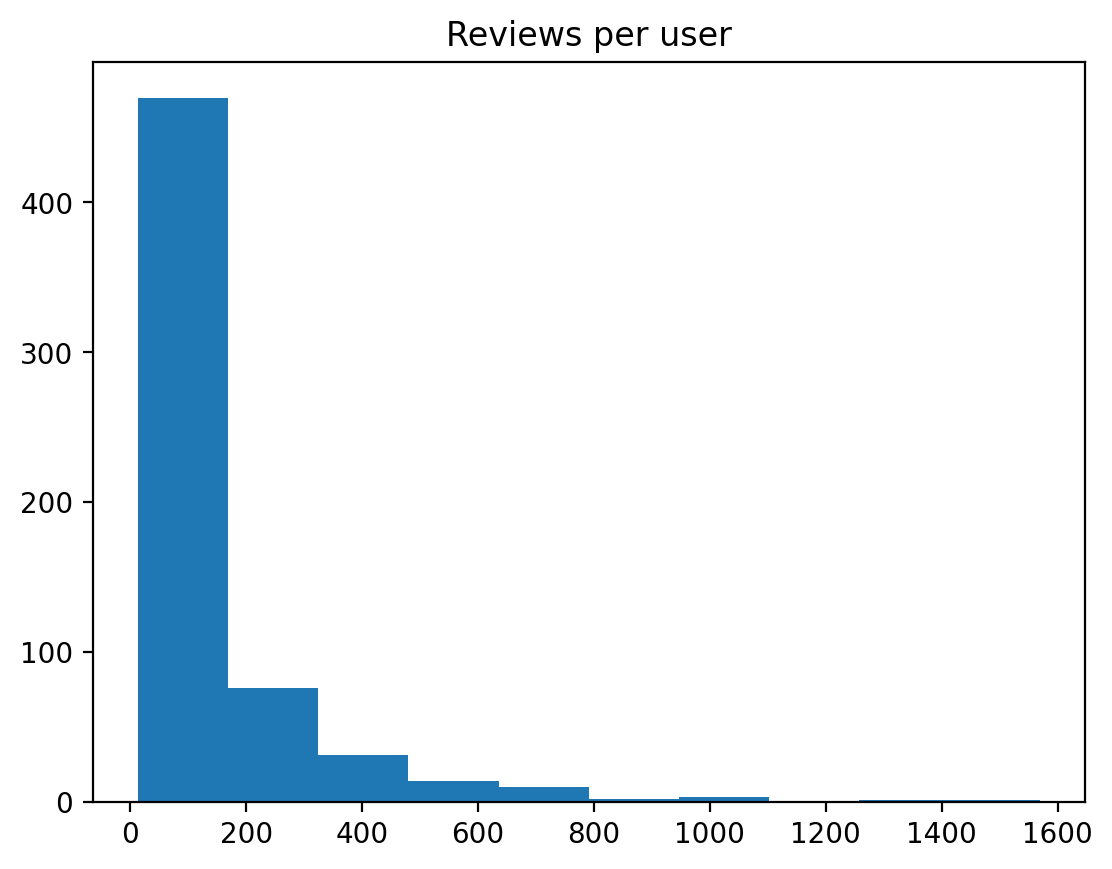

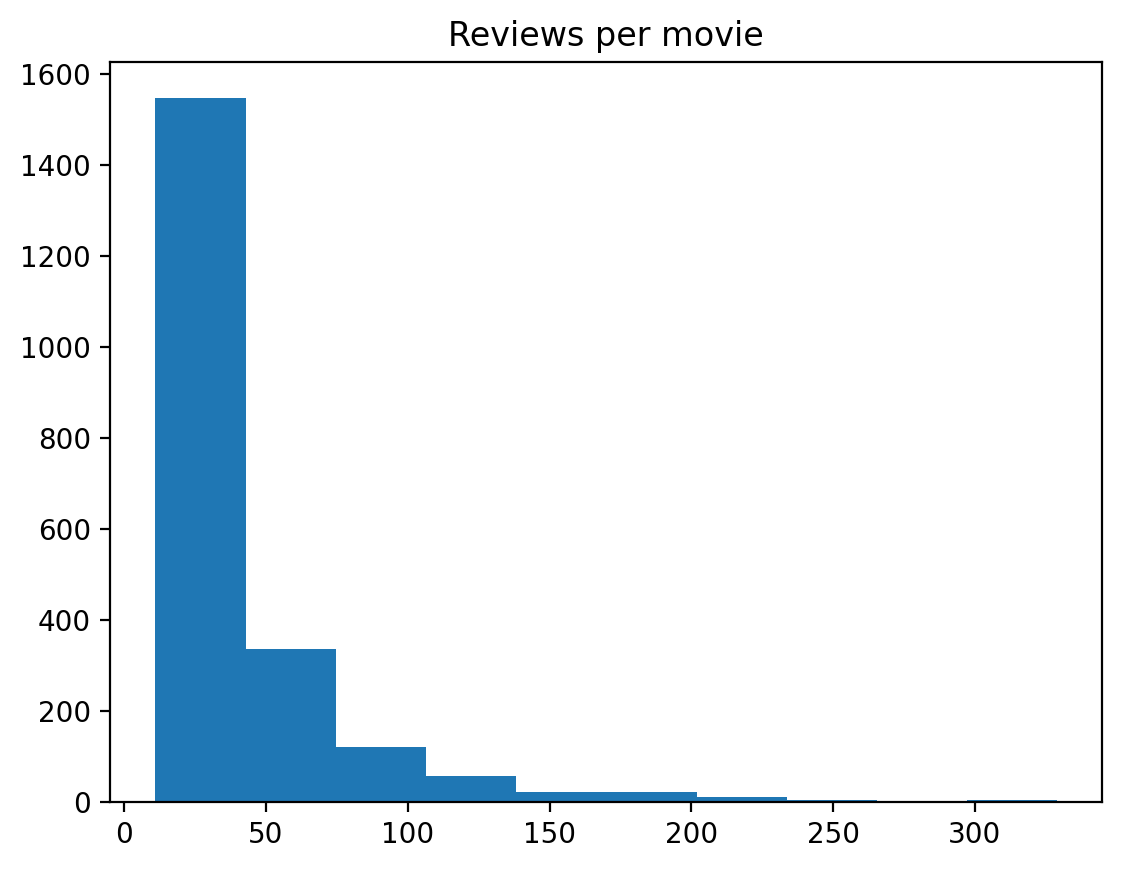

In [4]:
ml_df.groupby("uid").size().hist(grid=False)
plt.title("Reviews per user")
plt.show()
ml_df.groupby("iid").size().hist(grid=False)
plt.title("Reviews per movie")
plt.show()

In [5]:
ml_df.groupby("uid").mean()

,iid,rating
uid,,
0,654.354067,4.387560
1,1684.653846,3.980769
2,649.375000,1.479167
3,633.949153,3.593220
4,159.681818,3.636364
...,...,...
603,915.857374,3.668558
604,650.810651,3.781065
605,880.960110,3.193260


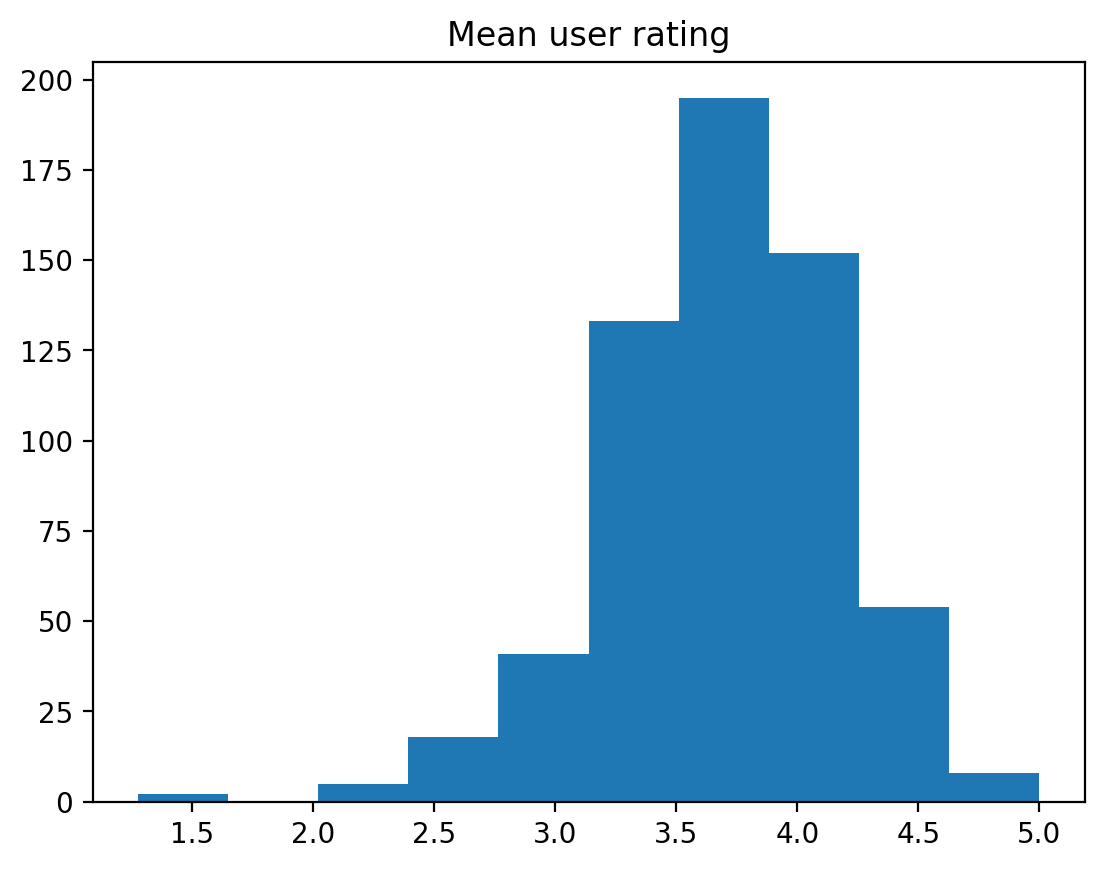

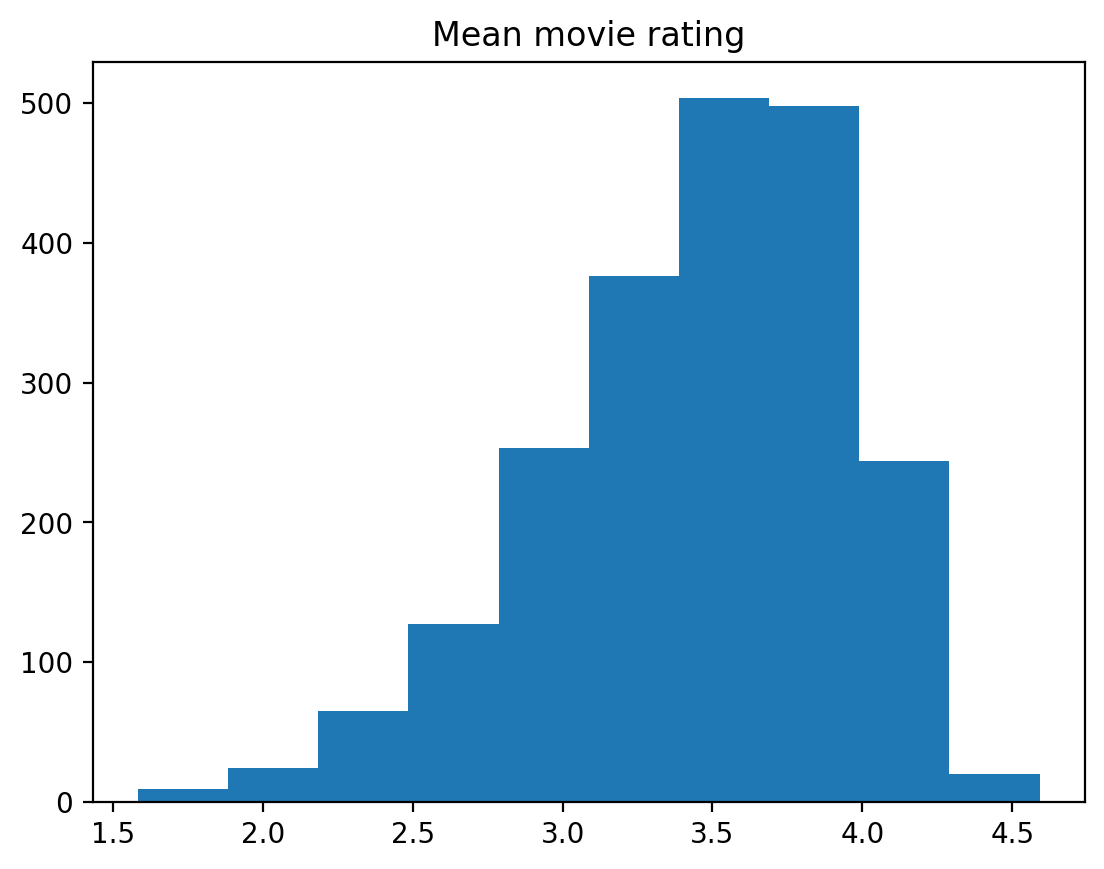

In [6]:
ml_df.groupby("uid").rating.mean().hist(grid=False)
plt.title("Mean user rating")
plt.show()
ml_df.groupby("iid").rating.mean().hist(grid=False)
plt.title("Mean movie rating")
plt.show()

In [7]:
sparsity = ml_df.size / ( ml_df.uid.nunique() * ml_df.iid.nunique())
print(f"Dataset sparsity is {sparsity:.2f}")

Dataset sparsity is 0.19


## Distances between users

Right was is to consider only overlapping items

In [8]:
user_codes = ml_df["uid"].astype("category").cat.codes
item_codes = ml_df["iid"].astype("category").cat.codes
R = coo_matrix((ml_df["rating"], (user_codes, item_codes)))
R = R.tocsr()
R = R[:10, :] # NOTE: consider only a fraction of users

In [9]:
def distance_shared_only(R, i, j, type): 
    ri = R.getrow(i)
    rj = R.getrow(j)
    shared = list(set(ri.indices) & set(rj.indices))
    if not shared:
        return np.inf
    ri = ri[0, shared].toarray().reshape(-1)
    rj = rj[0, shared].toarray().reshape(-1)
    if type == "euclidean":
        dist = np.linalg.norm(ri - rj)
    elif type == "cosine":
        cos_sim =  np.dot(ri, rj) / (np.linalg.norm(ri) * np.linalg.norm(rj))
        dist = 1 - cos_sim
    else:
        raise ValueError(f"Unknown distance type: {type}")
    return dist
def distances_shared_only(R, type):
    nrows = R.shape[0] 
    dist_mat = np.empty( (nrows, nrows) )
    for i in range(nrows):
        for j in range(i, nrows):
            dist = distance_shared_only(R, i, j, type)
            dist_mat[i,j] = dist_mat[j,i] = dist
    return dist_mat

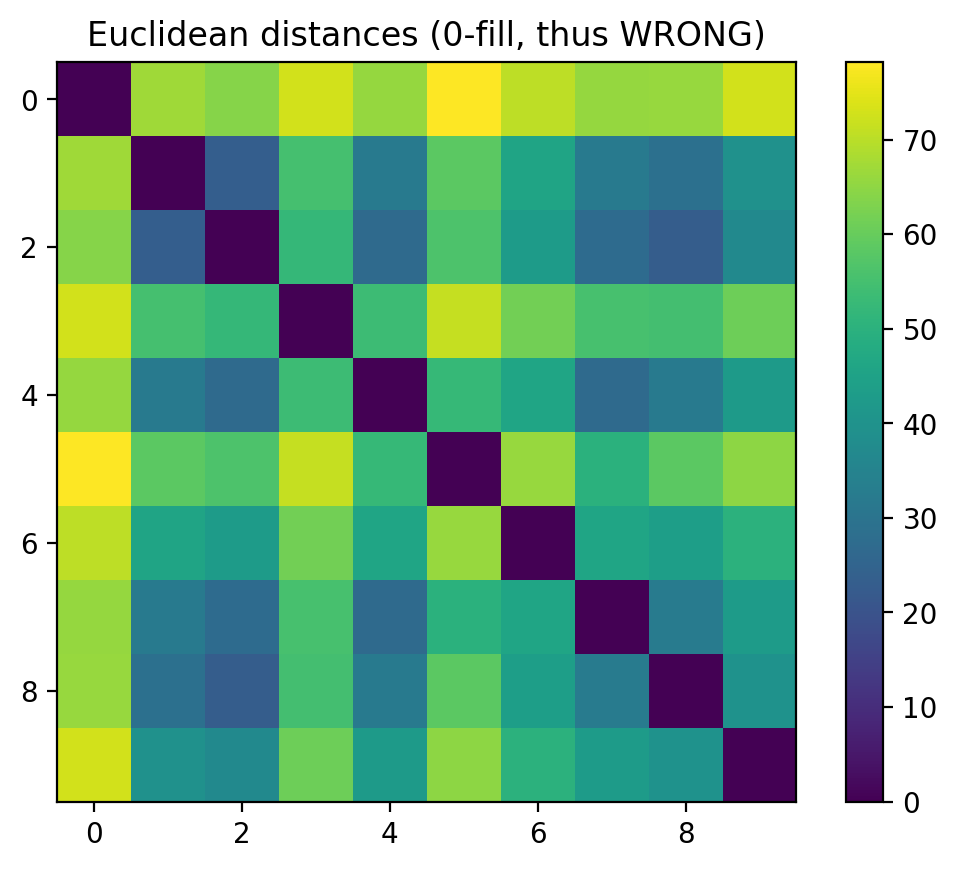

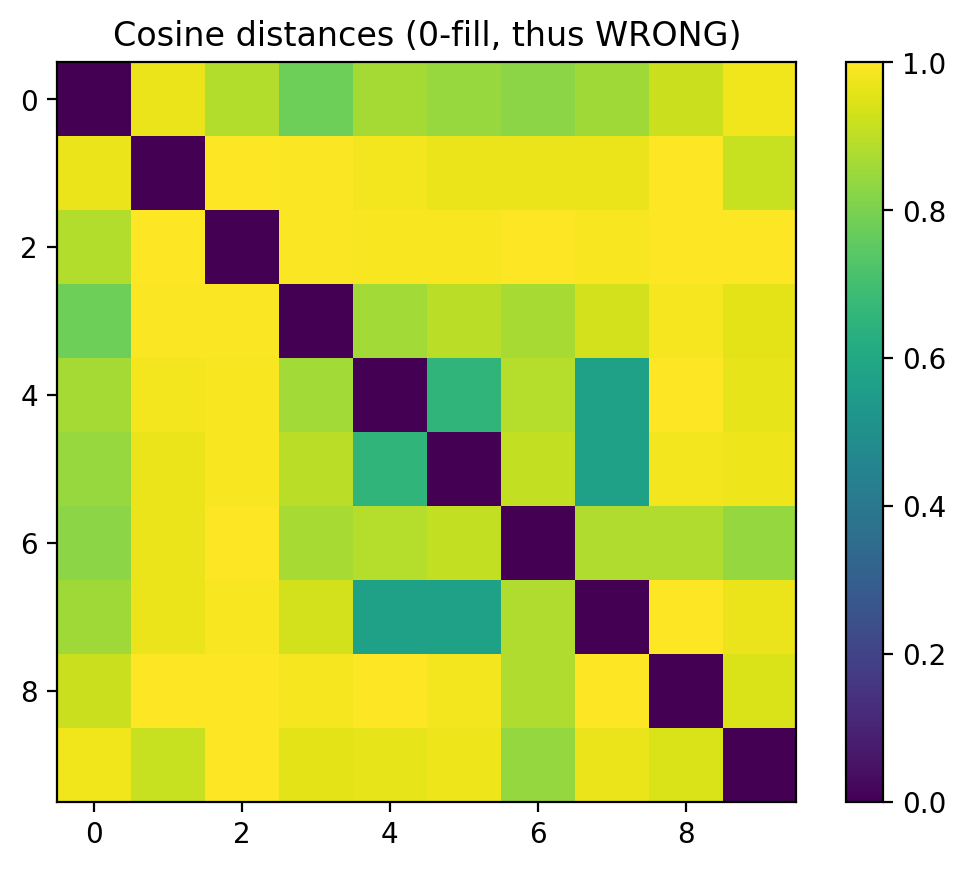

In [10]:
# NOTE: this strategy is bad since the sparse matrix implicitly treats missing values as 0
eucl_dist = euclidean_distances(R)
cos_dist = cosine_distances(R)
plt.imshow(eucl_dist)
plt.title("Euclidean distances (0-fill, thus WRONG)")
plt.colorbar()
plt.show()
plt.imshow(cos_dist)
plt.title("Cosine distances (0-fill, thus WRONG)")
plt.colorbar()
plt.show()

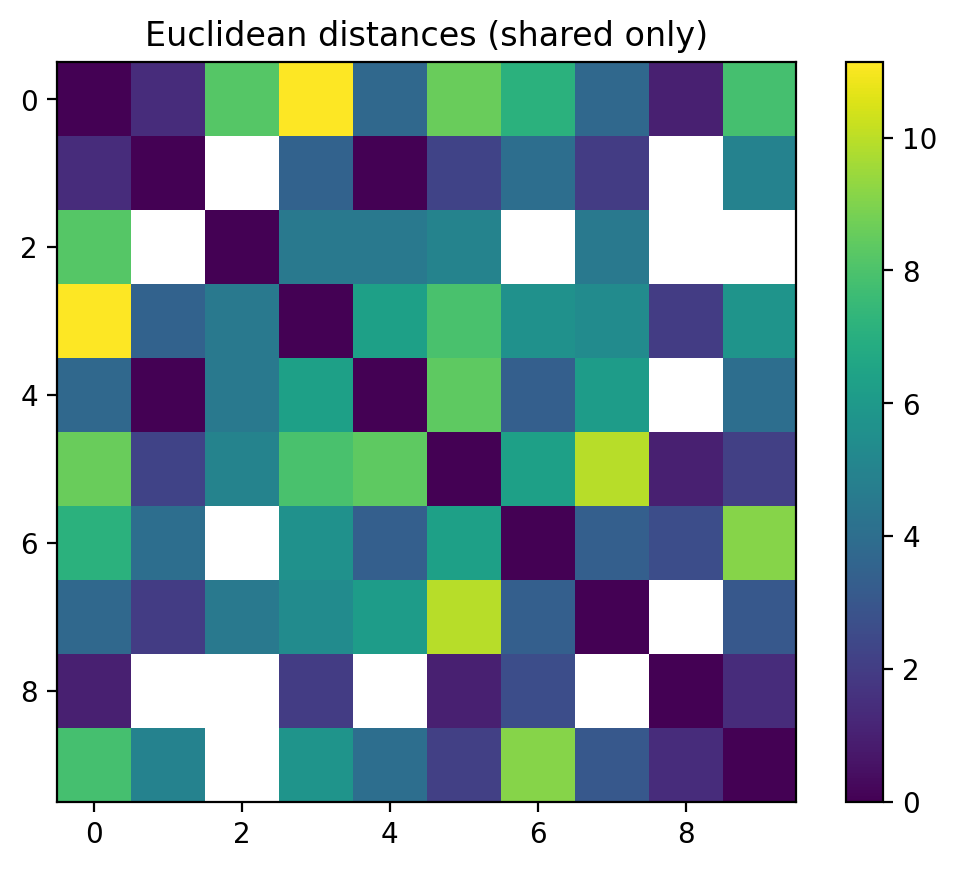

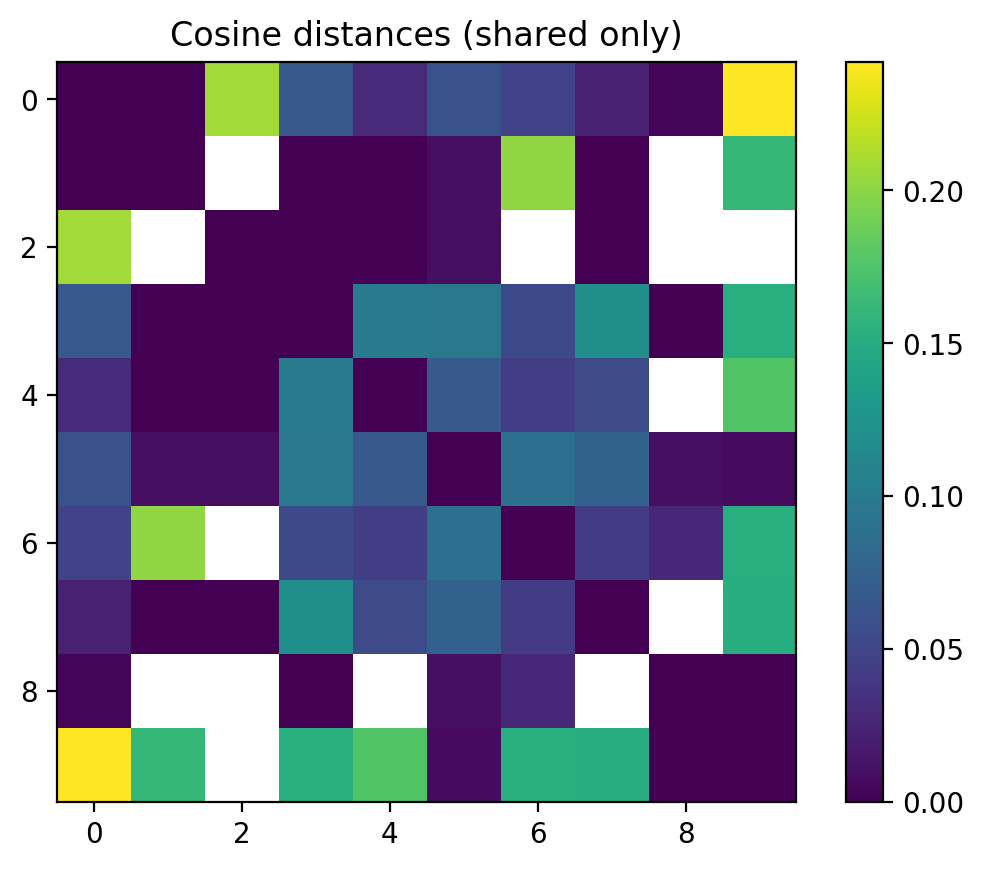

In [11]:
eucl_dist = distances_shared_only(R, "euclidean")
cos_dist = distances_shared_only(R, "cosine")
plt.imshow(eucl_dist)
plt.title("Euclidean distances (shared only)")
plt.colorbar()
plt.show()
plt.imshow(cos_dist)
plt.title("Cosine distances (shared only)")
plt.colorbar()
plt.show()

## Fit models from `surprise`

In [12]:
# 25% of ratings in test set
trainset, testset = train_test_split(ml_dataset, test_size=0.25)
print(f"Test set example:{testset[:2]}")

Test set example:[('144', '264', 4.0), ('540', '1405', 3.5)]


### `BaselineOnly`

$\hat{r_{ui}} = b_{ui} = \mu + b_u + b_i$

Predict ratings using the global mean adjusted by user and item bias terms. (The regularization is applied to bias terms, so it'snot that straightforward as computing averages).

In [13]:
algo = BaselineOnly(
    bsl_options={"method": "als", # NOTE: "als" for alternating least squares
                                  # or "sgd"
                 "n_epochs": 10, 
                 "reg_u": 0,#15, 
                 "reg_i": 0#10
                 }
)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions);

Estimating biases using als...
RMSE: 0.8482


This baseline seems to be pretty strong.

### `KNNBasic`

Basic CF algorithm, based on similarity between users or items - weighted average (by similarity) in the neighborhood.

In [14]:
algo = KNNBasic(
    k=40,
    min_k=1,
    sim_options={
        "name": "cosine",
        "user_based": False,  # similarities between items
    },
)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions);

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.9387


### `KNNWithMeans`

CF taking into account the mean ratings of each user / item. Equivalent to centering each rating to user's / item's mean.

In [15]:
algo = KNNWithMeans(
    k=40,
    min_k=1,
    sim_options={
        "name": "cosine",
        "user_based": False,  # similarities between items
    },
)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions);

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.8575


Better RMSE than for `KNNBasic`.

### `SVD`

It is not just the SVD you know from linear algebra!

$\hat{r_{ui}} = \mu + b_u + b_i + q_i ^Tp_u$

$q_i$ and $p_u$ are factors (basically low dimensional embeddings)

We could do SGD or ALS (since problem is bilinear and convex when item  or user vectors are fixed). Although SGD is preferred.

In [16]:
algo = SVD(n_factors=300, # 100 by default 
           n_epochs=20,
           biased=True, # if False, equivalent to Probabilistic Matrix Factorization,
           init_mean=0,
           init_std_dev=0.1,
           lr_all=0.05,
           reg_all=0.02
           )
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions);

RMSE: 0.8401


In [17]:
embeddings = algo.qi
labels = [iid2name[str(iid)] for iid in trainset.all_items()]

In [24]:
def plot_embeddings(X_tsne, clusters, labels):
    plt.figure(figsize=(10, 7))
    for cluster in np.unique(clusters):
        mask = clusters == cluster
        plt.scatter(
            X_tsne[mask, 0], X_tsne[mask, 1], label=f"cluster {cluster}", alpha=0.1
        )

    for iid, label in enumerate(labels):
        if iid % 5 == 0:
            plt.text(
                X_tsne[iid, 0],
                X_tsne[iid, 1],
                s=label[:15],
                alpha=0.8,
                fontsize=5,
                label=f"cluster {clusters[iid]}",
            )
    plt.tight_layout()

In [19]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(embeddings)
clusters = kmeans.labels_

tsne = TSNE(n_components=2, perplexity=30,)
movies_tsne = tsne.fit_transform(embeddings)

/Users/vlad/Documents/University/Master-MIND/M1-S2-MIND/ML/tme/tme07/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


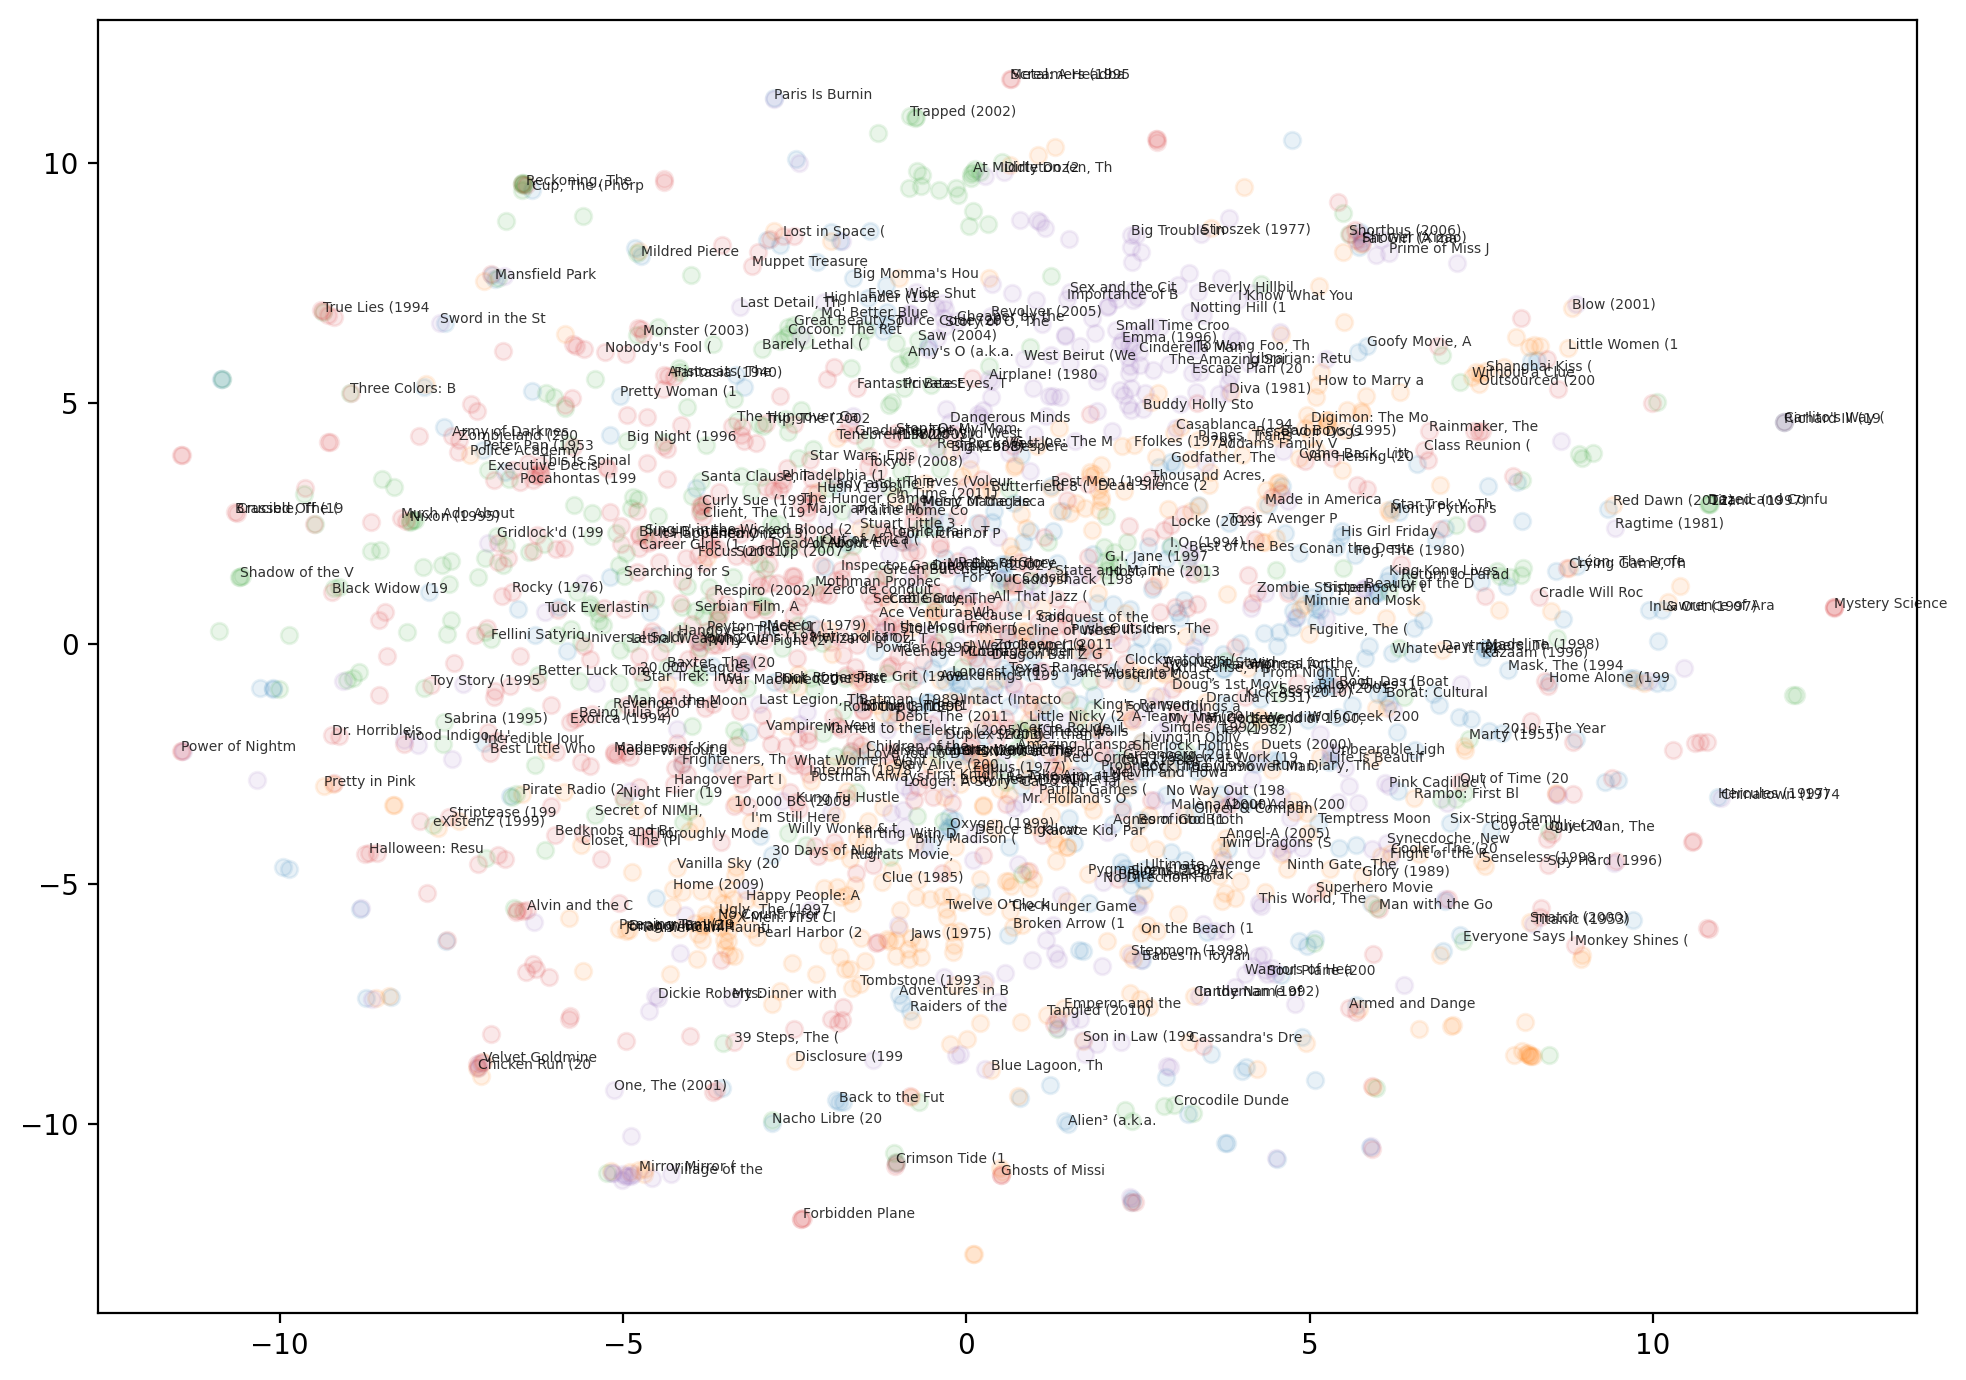

In [25]:
plot_embeddings(movies_tsne, clusters, labels)

Visualize embeddings interactively with tensorboard projector:

In [21]:
import tensorflow as tf
from tensorboard.plugins import projector
import os

log_dir = "./logs/embeddings"
os.makedirs(log_dir, exist_ok=True)

# 1. Save checkpoint — keyword name "embedding" → key becomes "embedding/.ATTRIBUTES/VARIABLE_VALUE"
embedding_var = tf.Variable(embeddings, name="word_embeddings", dtype=tf.float32)
checkpoint = tf.train.Checkpoint(embedding=embedding_var)
checkpoint.save(os.path.join(log_dir, "embedding.ckpt"))

# 2. Write metadata
metadata_path = os.path.join(log_dir, "metadata.tsv")
with open(metadata_path, "w") as f:
    for label in labels:
        f.write(label + "\n")   # ← NO header line unless you explicitly want a column header

# 3. Configure projector — tensor_name must match checkpoint key exactly
config = projector.ProjectorConfig()
emb_config = config.embeddings.add()
emb_config.tensor_name = "embedding/.ATTRIBUTES/VARIABLE_VALUE"
emb_config.metadata_path = "metadata.tsv"   # relative to log_dir

projector.visualize_embeddings(log_dir, config)

### `NMF`

CF based on Non-negative Matrix Factorization. Similar to SVD, but with factors kept positive.

$\hat{r_{ui}} = q_i ^Tp_u \quad \forall f \ {q_i}_f, {p_u}_f \geq 0$ 

There is a biased version as well.

Note that it has a smart SGD update - factors get scaled by some non-negative ratio (can be deduced from classical SGD with additive update rule)!

In [26]:
algo = NMF(n_factors=15, # 15 by default 
           n_epochs=20,
           biased=False,)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions);

RMSE: 0.8898


In [27]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(embeddings)
clusters = kmeans.labels_

tsne = TSNE(n_components=2, perplexity=30,)
movies_tsne = tsne.fit_transform(embeddings)

/Users/vlad/Documents/University/Master-MIND/M1-S2-MIND/ML/tme/tme07/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


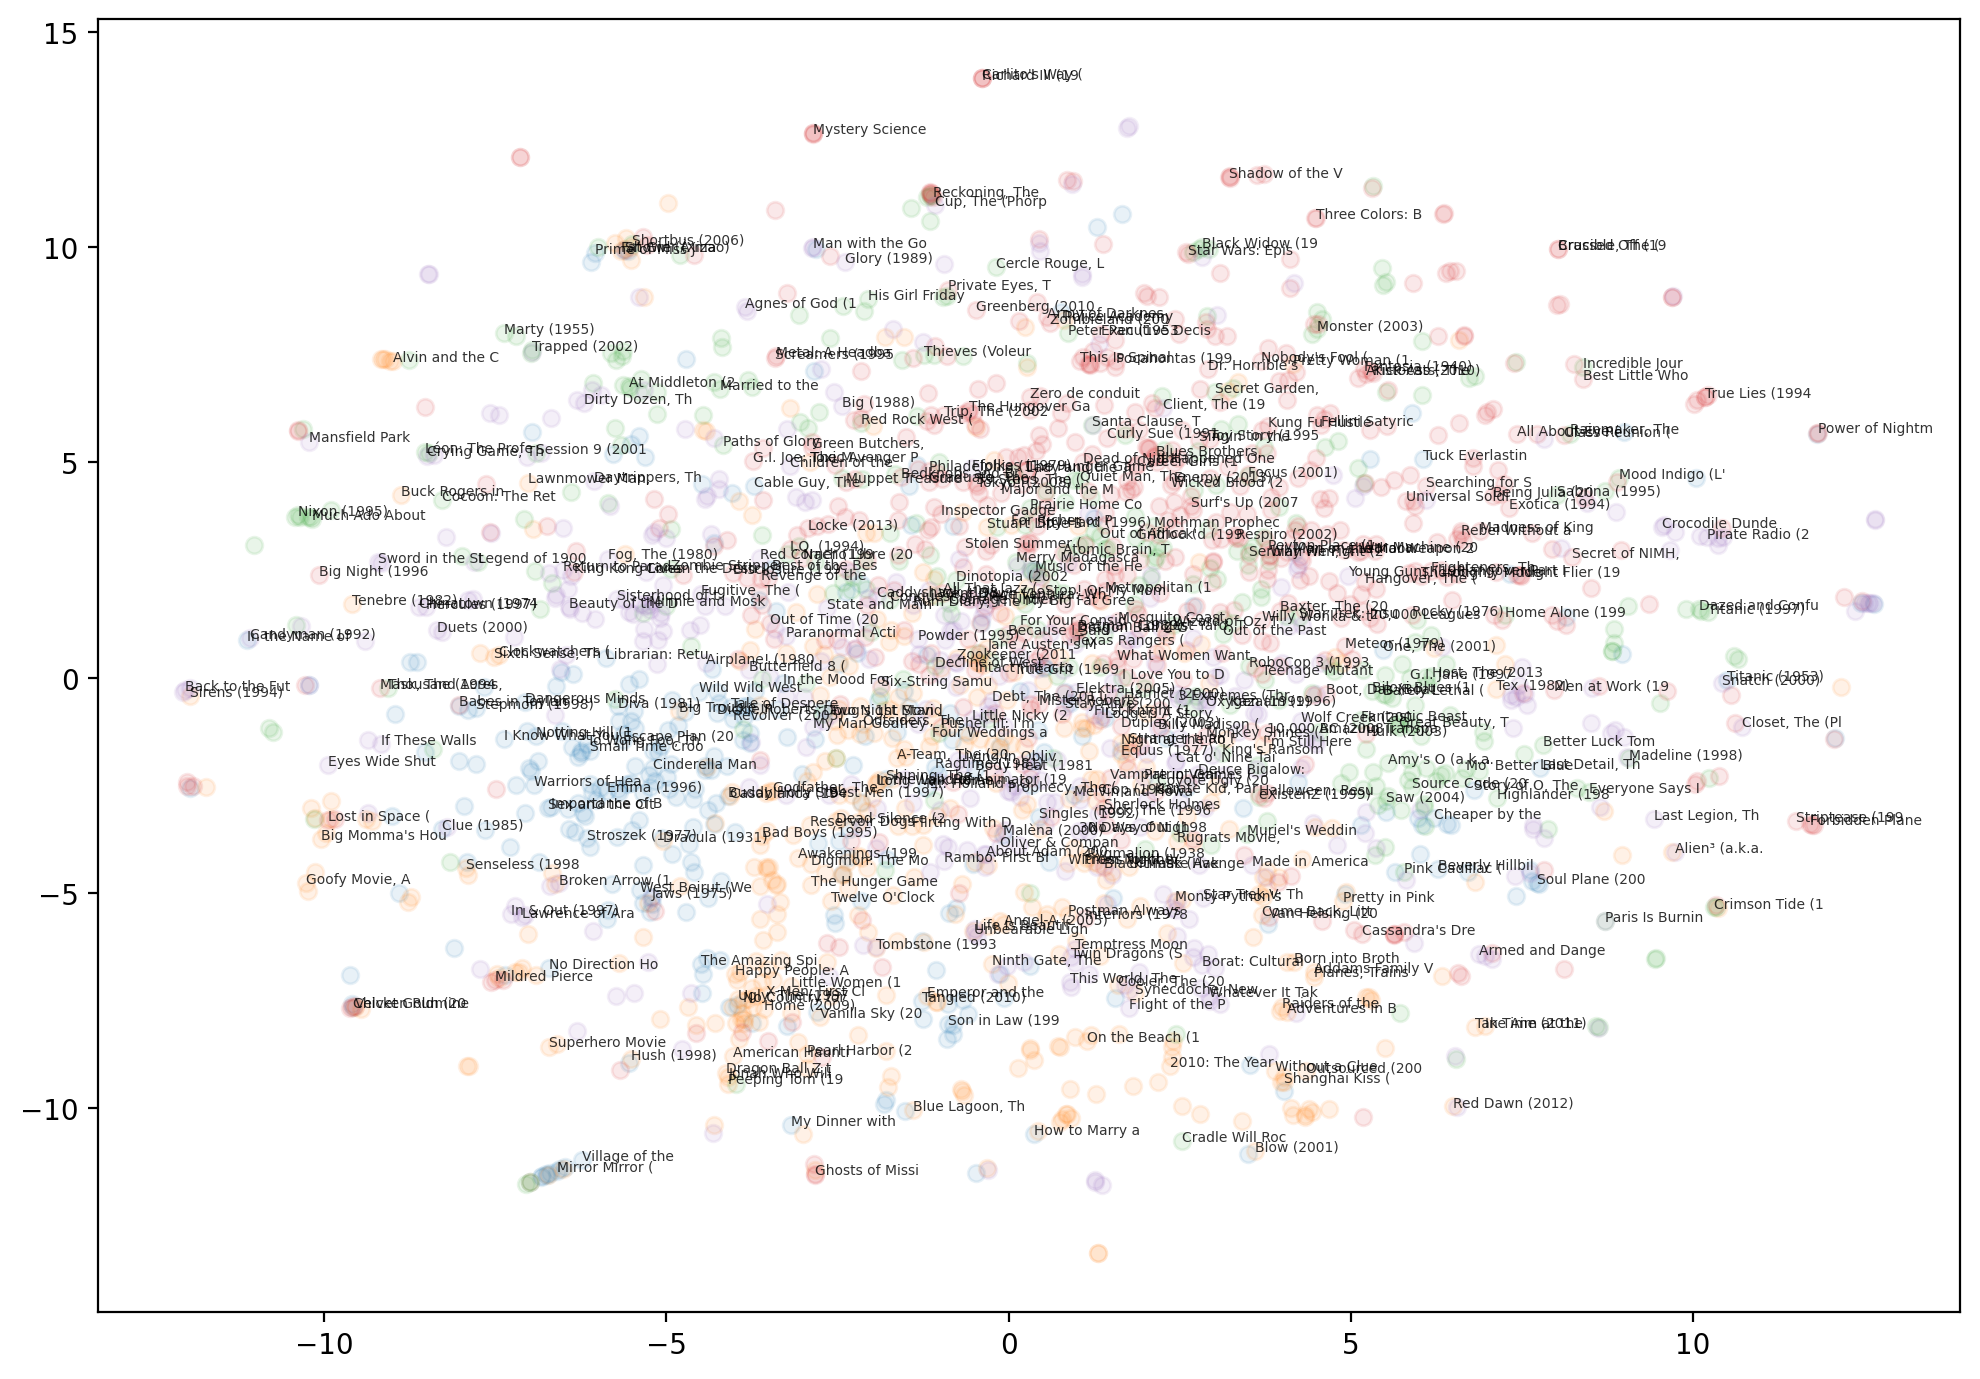

In [28]:
plot_embeddings(movies_tsne, clusters, labels)